# `00_intro.ipynb`
## Langchain Intro
```sh
uv add langchain langchain_openai langchain_core langchain_community
```
## 한줄 요약
- Langchain == Agent Builder다.

In [1]:
# 환경변수(.env) 내용을 로드
from dotenv import load_dotenv

load_dotenv()

True

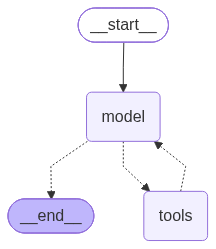

In [2]:
from langchain.agents import create_agent
# 메모리 추가
from langgraph.checkpoint.memory import InMemorySaver


# 매개변수 city에 들어갈 데이터 타입은 str이다.
def get_weather(city: str):
    '''주어진 도시의 날씨를 확인하는 Tool'''  # Tool Description (설명서)
    return f'{city}는 화창합니다.'


# 이름: calculator. 매개변수 num1, num2 (float), opr (str)
def calculator(num1: float, num2: float, opr: str):
    '''opr을 보고 num1 과 num2의 사칙연산을 진행
    opr 은 '+', '-'만 사용 가능
    '''
    if opr == '+':
        return num1 + num2
    elif opr == '-':
        return num1 - num2

memory = InMemorySaver()

agent = create_agent(
    model='openai:gpt-4.1-mini',
    tools=[get_weather, calculator],
    system_prompt="You are a helpful assistant. Answer in KOR",
    checkpointer=memory,  # 메모리
)

agent

In [3]:
# 메모리에서 대화 내역을 구분할 key 가 필요
thread_config = {
    'configurable': {'thread_id': '1234'}  # 세션 번호
}

# 에이전트 실행
agent.invoke(
    # 1번인자: 메세지
    {
        'messages': [
            {'role': 'user', 'content': '아까 최종 계산 결과 얼마였지?'}
        ]
    },
    # 2번인자: 설정
    thread_config,
)

{'messages': [HumanMessage(content='아까 최종 계산 결과 얼마였지?', additional_kwargs={}, response_metadata={}, id='82c35ab9-9ba3-4ebf-a38d-d68d9855e3ad'),
  AIMessage(content='죄송하지만 이전 대화 내역을 확인할 수 없어서 최종 계산 결과가 얼마였는지 알 수 없습니다. 다시 계산해 드릴까요? 계산할 내용을 알려주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 118, 'total_tokens': 159, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_bb832114e0', 'id': 'chatcmpl-EJubWivHOhrOivkjucZJpXB4Wx0Qg', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a065d0-0406-70a1-9ee0-d4e62c0a782c-0', tool_calls=[], invalid_tool_calls=[

In [ ]:
# 대화형 UI
user_input = input()

thread_config = {
    'configurable': {'thread_id': '4567'}  # 세션 번호
}

while user_input != '종료':
    print('사용자:', user_input)
    result = agent.invoke(
        {'messages': [{'role': 'user', 'content': user_input}]},
        thread_config,
    )
    print('AI:', result['messages'][-1].content)
    user_input = input()

## 실습

- 로또 Agent 만들기
- Tool
    - 함수이름: `get_lotto_info`
    - `requests` 로 요청 보내는 도구
    - url : `https://www.dhlottery.co.kr/lt645/selectPstLt645Info.do?srchStrLtEpsd=1232&srchEndLtEpsd=1232`
    - `srchStrLtEpsd` : 조회 시작 회차
    - `srchEndLtEpsd` : 조회 종료 회차
    - 매개변수: `start_round: int, end_round: int` (각각 조회할 때 시작회차와 마지막 회차의 번호)
    - 설명(description): LLM이 잘 사용할 수 있도록 작성
- Memory
    - `InMemorySaver`
    - `thread_id` 는 편한대로
- Model
    - `openai:gpt-4.1-mini`
- System Prmopt
    - 잘 동작하도록 작성
    - 오늘 날짜 + 시간 넣기 (검색 필요)
    - 오늘 날짜 기준 최신회차는 1239
- 대화형 UI로 만들기
- 예시 대화
    - Q: 가장 최근회차의 1등 당첨금액은 얼마야? -> A: 22.1억
    - Q: 저번 회차는 몇명이 1등 당첨됐어? -> A: 23명


In [ ]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
import requests
from datetime import datetime

lotto_memory = InMemorySaver()

system_prompt = f'''
오늘 날짜: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

너는 로또 정보를 가져와서 알려주는 agent야.
오늘 날짜 기준 마지막 추첨일과 회차는 2026-08-29 (토), 1239회차야.

Tool 중에 get_lotto_info 를 사용해야해.

로또와 관련 없는 질문은 정중하게 거절해.
'''


# Tool 만들기
def get_lotto_info(start_round: int, end_round: int):
    '''로또 정보를 가져오는 tool
    단일 회차 조회시, start_round == end_round
    회차 범위 조회시 적절한 start_round 와 end_round를 지정해야함

    - start_round: 조회하고자 하는 회차 범위의 가장 빠른 회차
    - end_round : 조회하고자 하는 회차 범위의 가장 늦은 회차'''

    URL = f'https://www.dhlottery.co.kr/lt645/selectPstLt645Info.do?srchStrLtEpsd={start_round}&srchEndLtEpsd={end_round}'
    res = requests.get(URL)
    data = res.json()
    # 로또 데이터 정제
    parsed_result = []

    for item in data['data']['list']:
        # YYYYMMDD 형태의 날짜를 YYYY-MM-DD 포맷으로 정제
        raw_date = str(item.get("ltRflYmd", ""))
        draw_date = (
            f"{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:]}"
            if len(raw_date) == 8
            else raw_date
        )
        parsed_result.append(
            {
                "draw_no": item.get("ltEpsd"),  # 회차
                "draw_date": draw_date,  # 추첨 날짜
                "numbers": sorted(
                    [item[f"tm{i}WnNo"] for i in range(1, 7)]
                ),  # 당첨 번호 6개
                "bonus_number": item.get("bnsWnNo"),  # 보너스 번호
                "prize": {
                    "first_amount": item.get("rnk1WnAmt", 0),  # 1등 1인당 당첨금
                    "first_winner_count": item.get(
                        "rnk1WnNope", 0
                    ),  # 1등 당첨자 수
                    "first_total_amount": item.get(
                        "rnk1SumWnAmt", 0
                    ),  # 1등 총 당첨금
                    "total_sell_amount": item.get(
                        "wholEpsdSumNtslAmt", 0
                    ),  # 해당 회차 총 판매금액
                },
            }
        )
    return parsed_result



In [ ]:
# Structured Output 지정하기 (아래는 예시)
'''
{
    'user_input' : 원본 사용자 질문
    'answer': AI가 작성한 답변
}
'''
from pydantic import BaseModel, Field

class UserResponse(BaseModel):
    user_input: str = Field(description="원본 사용자 질문")
    answer: str = Field(description="AI가 작성한 답변")

In [ ]:
# Agent 생성    

lotto_agent = create_agent(
    model='openai:gpt-4.1-mini',
    tools=[get_lotto_info],
    checkpointer=lotto_memory,
    system_prompt=system_prompt,
    response_format=UserResponse,
)

In [ ]:
thread_config = {
    'configurable': {'thread_id': 'asdf'}  # 세션 번호
}

user_input = input()
while user_input != '종료':
    print('사용자:', user_input)

    # result = lotto_agent.invoke(
    #     {'messages': [{'role': 'user', 'content': user_input}]},
    #     thread_config,
    # )
    
    # 터미널 or 노트북에서 답변 스트리밍 하기 (나중에는 사용하지 않음)
    stream = lotto_agent.stream_events(
        {'messages': [{'role': 'user', 'content': user_input}]},
        thread_config,
        version='v3'
    )

    for message in stream.messages:
        for delta in message.text:
            print(delta, end="", flush=True)

    user_input = input()